In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_csv("/content/Students suspicious behaviors detection dataset_V1.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (5500, 38)
   face_present  no_of_face      face_x      face_y      face_w      face_h  \
0             1           1  262.579536  312.062903  151.787758  151.787567   
1             1           1  260.704193  312.342424  154.607773  154.607735   
2             1           1  264.240570  311.801834  148.079300  148.079195   
3             1           1  262.811012  314.088278  151.014061  151.014175   
4             1           1  269.176426  312.678709  148.739681  148.739605   

   left_eye_x  left_eye_y  right_eye_x  right_eye_y  ...  phone_conf  \
0  307.918568  354.478884   373.059845   353.494949  ...         0.0   
1  305.797863  354.197273   372.084160   357.747831  ...         0.0   
2  304.438133  351.268072   368.618050   353.264036  ...         0.0   
3  304.091930  355.737219   369.532318   355.841103  ...         0.0   
4  310.720120  354.326448   374.389267   350.510445  ...         0.0   

   gaze_on_script  gaze_direction  gazePoint_x  gazePoint_y  pupil_left_x 

In [5]:
print("\nNull values in each column:")
print(df.isnull().sum())


Null values in each column:
face_present               0
no_of_face                 0
face_x                     0
face_y                     0
face_w                     0
face_h                     0
left_eye_x                 0
left_eye_y                 0
right_eye_x                0
right_eye_y                0
nose_tip_x                 0
nose_tip_y                 0
mouth_x                    0
mouth_y                    0
face_conf                  0
hand_count                 0
left_hand_x                0
left_hand_y                0
right_hand_x               0
right_hand_y               0
hand_obj_interaction       0
head_pose                569
head_pitch                 0
head_yaw                   0
head_roll                  0
phone_present              0
phone_loc_x                0
phone_loc_y                0
phone_conf                 0
gaze_on_script             0
gaze_direction          1051
gazePoint_x                0
gazePoint_y                0
pupil_left_x  

In [6]:
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Duplicate rows: 76
Shape after removing duplicates: (5424, 38)



Class distribution:
label
0    2881
1    2543
Name: count, dtype: int64


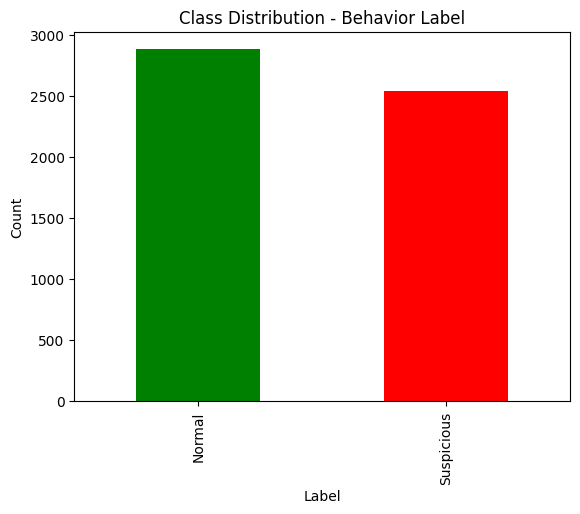

In [7]:
print("\nClass distribution:")
print(df['label'].value_counts())

df['label'].value_counts().rename({0: 'Normal', 1: 'Suspicious'}).plot(
    kind='bar', color=['green', 'red']
)
plt.title("Class Distribution - Behavior Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


Multiclass Distribution:
risk_level
0    2881
2    1947
1     596
Name: count, dtype: int64


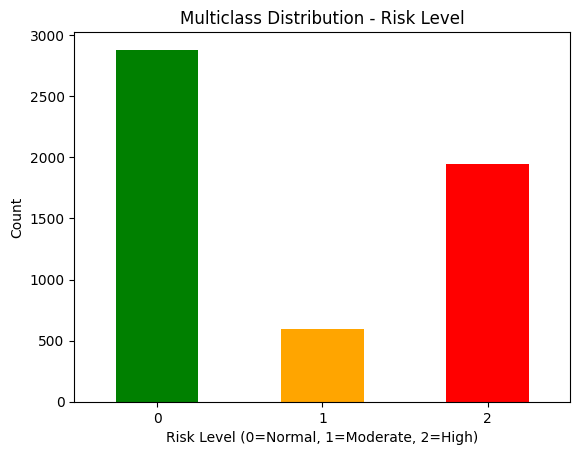

In [8]:
def assign_risk(row):
    if row['phone_present'] == 1:
        return 2  # High Risk
    elif row['label'] == 1 and row['gaze_on_script'] == 0:
        return 2  # High Risk
    elif row['label'] == 1:
        return 1  # Moderate Risk
    else:
        return 0  # Normal

df['risk_level'] = df.apply(assign_risk, axis=1)

print("\nMulticlass Distribution:")
print(df['risk_level'].value_counts())

df['risk_level'].value_counts().sort_index().plot(
    kind='bar', color=['green', 'orange', 'red']
)
plt.title("Multiclass Distribution - Risk Level")
plt.xlabel("Risk Level (0=Normal, 1=Moderate, 2=High)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [9]:
categorical_cols = ['head_pose', 'gaze_direction']

for col in categorical_cols:
    df[col] = df[col].fillna('unknown')

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nClasses (risk_level): 0=Normal, 1=Moderate Risk, 2=High Risk")
print(df.head())


Classes (risk_level): 0=Normal, 1=Moderate Risk, 2=High Risk
   face_present  no_of_face      face_x      face_y      face_w      face_h  \
0             1           1  262.579536  312.062903  151.787758  151.787567   
1             1           1  260.704193  312.342424  154.607773  154.607735   
2             1           1  264.240570  311.801834  148.079300  148.079195   
3             1           1  262.811012  314.088278  151.014061  151.014175   
4             1           1  269.176426  312.678709  148.739681  148.739605   

   left_eye_x  left_eye_y  right_eye_x  right_eye_y  ...  gaze_on_script  \
0  307.918568  354.478884   373.059845   353.494949  ...               1   
1  305.797863  354.197273   372.084160   357.747831  ...               1   
2  304.438133  351.268072   368.618050   353.264036  ...               1   
3  304.091930  355.737219   369.532318   355.841103  ...               1   
4  310.720120  354.326448   374.389267   350.510445  ...               1   

   gaz

In [10]:
X = df.drop(columns=['label', 'risk_level'])
y = df['risk_level']

print("\nX shape:", X.shape)
print("y distribution:\n", y.value_counts())


X shape: (5424, 37)
y distribution:
 risk_level
0    2881
2    1947
1     596
Name: count, dtype: int64


In [11]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nBefore SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())


Before SMOTE: {0: 2881, 2: 1947, 1: 596}
After SMOTE: {0: 2881, 2: 2881, 1: 2881}


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print("\nTraining size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (6914, 37)
Testing size: (1729, 37)


In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nScaling done!")


Scaling done!


In [14]:
log_model = LogisticRegression(
    solver='saga',
    max_iter=5000
)


log_model.fit(X_train, y_train)


y_pred_log = log_model.predict(X_test)

print("\nMultinomial Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(
    y_test, y_pred_log,
    target_names=['Normal (0)', 'Moderate Risk (1)', 'High Risk (2)']
))


Multinomial Logistic Regression Accuracy: 0.9583574320416426

Classification Report:

                   precision    recall  f1-score   support

       Normal (0)       0.93      0.95      0.94       589
Moderate Risk (1)       0.95      0.94      0.94       554
    High Risk (2)       0.99      0.99      0.99       586

         accuracy                           0.96      1729
        macro avg       0.96      0.96      0.96      1729
     weighted avg       0.96      0.96      0.96      1729



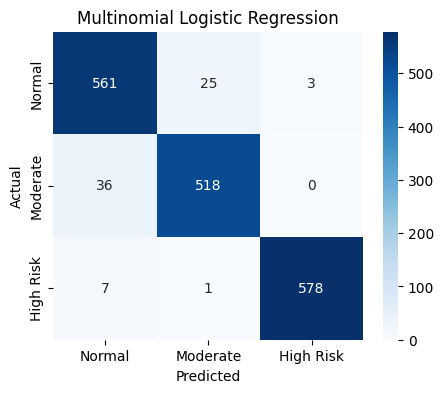

In [15]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Moderate', 'High Risk'],
            yticklabels=['Normal', 'Moderate', 'High Risk'])

plt.title("Multinomial Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()